# Disneyland Reviews — Supervised Baselines

**Team 4 — Sentiment Analysis (NLP).** Machine Learning 2026-III.

Workshop #1 deliverable: baseline classifiers on the engineered features. This
notebook *presents* the results — all training lives in `src/baselines.py`, so the
numbers here are reproducible from the command line (`python -m src.baselines`).

Evaluation is on the **validation** split; the test split is kept untouched for the
final comparison in later workshops.

## 1. Imports and training

`run()` trains the baselines once and returns their metrics plus confusion
matrices. Nothing is re-trained in this notebook.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.baselines import run
from src import plots

plots.apply_theme()
results = run()  # trains all four baselines and evaluates them on validation

/home/juliancelis/.cache/pypoetry/virtualenvs/ml-npl-IPkIm5Ic-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Baseline 0 - Majority class
accuracy : 0.7953
AUC-ROC  : 0.5000 (one-vs-rest, macro)
macro-F1 : 0.2953  <- headline metric

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       543
     neutral       0.00      0.00      0.00       766
    positive       0.80      1.00      0.89      5086

    accuracy                           0.80      6395
   macro avg       0.27      0.33      0.30      6395
weighted avg       0.63      0.80      0.70      6395

confusion matrix (rows = true, cols = predicted):
              negative   neutral  positive
  negative           0         0       543
   neutral           0         0       766
  positive           0         0     5,086



Baseline 1 - Logistic Regression
accuracy : 0.7844
AUC-ROC  : 0.8866 (one-vs-rest, macro)
macro-F1 : 0.6258  <- headline metric

              precision    recall  f1-score   support

    negative       0.52      0.71      0.60       543
     neutral       0.32      0.49      0.39       766
    positive       0.95      0.84      0.89      5086

    accuracy                           0.78      6395
   macro avg       0.60      0.68      0.63      6395
weighted avg       0.84      0.78      0.81      6395

confusion matrix (rows = true, cols = predicted):
              negative   neutral  positive
  negative         387       125        31
   neutral         215       379       172
  positive         146       690     4,250



Baseline 2 - Random Forest
accuracy : 0.7961
AUC-ROC  : 0.8618 (one-vs-rest, macro)
macro-F1 : 0.3016  <- headline metric

              precision    recall  f1-score   support

    negative       0.71      0.01      0.02       543
     neutral       0.00      0.00      0.00       766
    positive       0.80      1.00      0.89      5086

    accuracy                           0.80      6395
   macro avg       0.50      0.34      0.30      6395
weighted avg       0.69      0.80      0.71      6395

confusion matrix (rows = true, cols = predicted):
              negative   neutral  positive
  negative           5         0       538
   neutral           2         0       764
  positive           0         0     5,086



Baseline 3 - Multinomial Naive Bayes
accuracy : 0.8027
AUC-ROC  : 0.8187 (one-vs-rest, macro)
macro-F1 : 0.4318  <- headline metric

              precision    recall  f1-score   support

    negative       0.55      0.17      0.26       543
     neutral       0.34      0.09      0.14       766
    positive       0.83      0.98      0.89      5086

    accuracy                           0.80      6395
   macro avg       0.57      0.41      0.43      6395
weighted avg       0.74      0.80      0.75      6395

confusion matrix (rows = true, cols = predicted):
              negative   neutral  positive
  negative          94        66       383
   neutral          29        66       671
  positive          48        65     4,973

SUMMARY (validation)
model                                   accuracy   AUC-ROC  macro-F1
Baseline 1 - Logistic Regression          0.7844    0.8866    0.6258
Baseline 3 - Multinomial Naive Bayes      0.8027    0.8187    0.4318
Baseline 2 - Random Forest        

## 2. Comparison

The headline metric is **macro-F1**, not accuracy — with 79.5% of reviews positive,
accuracy rewards a model that ignores the minority classes.

In [2]:
table = pd.DataFrame(
    [{'model': r['model'], 'accuracy': r['accuracy'],
      'AUC-ROC': r['auc_roc'], 'macro_f1': r['macro_f1']}
     for r in results]
).set_index('model').sort_values('macro_f1', ascending=False)
table.round(4)

,accuracy,AUC-ROC,macro_f1
model,,,
Baseline 1 - Logistic Regression,0.7844,0.8866,0.6258
Baseline 3 - Multinomial Naive Bayes,0.8027,0.8187,0.4318
Baseline 2 - Random Forest,0.7961,0.8618,0.3016
Baseline 0 - Majority class,0.7953,0.5000,0.2953


**Read the columns against each other — they disagree, and the disagreement is the
result.**

Three of the four models beat Logistic Regression on **accuracy**. All four lose to it on
**macro-F1**. Multinomial Naive Bayes reaches the highest accuracy of any model here while
scoring a macro-F1 well below the linear model: ranking by accuracy would have selected
one of the weaker classifiers.

The reason is the 9.4:1 imbalance. Accuracy counts every review once, so ignoring the
8.5% negative class is cheap; macro-F1 averages the three per-class F1 scores without
weighting, so it is not.

**AUC-ROC adds a third reading, and it splits the Random Forest in two.** Its AUC of
0.8618 says the probabilities it assigns *rank* reviews well. Its macro-F1 of 0.3016 says
the labels it *chooses* are close to the majority baseline. Those measure different
things — the quality of the ranking versus the quality of the argmax cut — so the gap
points at the decision threshold rather than at the model.

The majority baseline's AUC is exactly **0.5000**, which is the sanity check: a constant
prediction carries no ranking information at all.

## 3. Confusion matrices

Rows are the true class, columns the prediction. Shading is normalised per row, so
colour reads as recall; the numbers are raw counts.

/home/juliancelis/Documents/universidad/noveno_semestre/ML/ML_NPL/src/plots.py:316: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  shade = np.divide(matrix, row_totals, where=row_totals != 0)
/home/juliancelis/Documents/universidad/noveno_semestre/ML/ML_NPL/src/plots.py:316: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  shade = np.divide(matrix, row_totals, where=row_totals != 0)
/home/juliancelis/Documents/universidad/noveno_semestre/ML/ML_NPL/src/plots.py:316: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  shade = np.divide(matrix, row_totals, where=row_totals != 0)
/home/juliancelis/Documents/universidad/noveno_semestre/ML/ML_NPL/src/plots.py:316: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  s

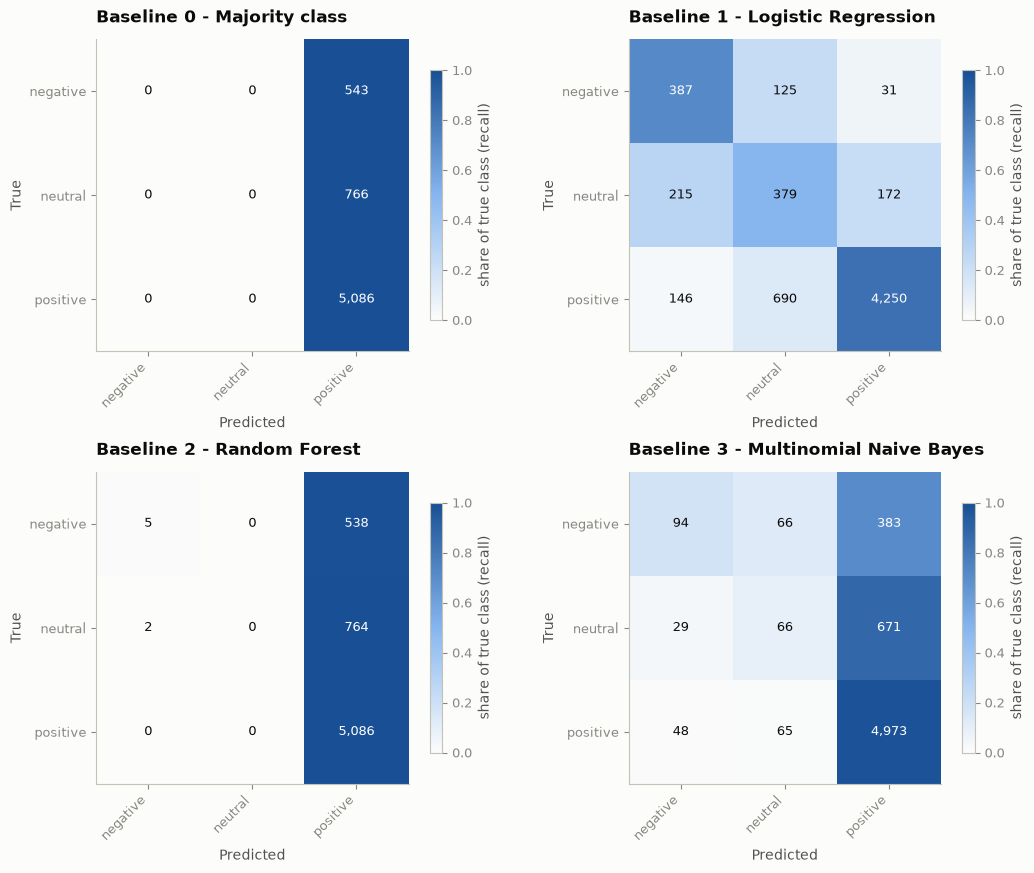

In [3]:
# 2x2 rather than one row: four matrices side by side would be 21 inches wide.
n = len(results)
rows, cols = (2, 2) if n > 2 else (1, n)
fig, axes = plt.subplots(rows, cols, figsize=(5.4 * cols, 4.4 * rows))
flat = axes.ravel() if hasattr(axes, 'ravel') else [axes]
for ax, r in zip(flat, results):
    plots.confusion_heatmap(r['confusion'], r['labels'], title=r['model'], ax=ax)
for ax in flat[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Reading the results

Per-class recall on validation — the number the headline metrics are hiding:

| Model | negative | neutral | positive |
| --- | --- | --- | --- |
| Logistic Regression | **0.713** | **0.495** | 0.836 |
| Multinomial Naive Bayes | 0.173 | 0.086 | 0.978 |
| Random Forest | 0.009 | **0.000** | 1.000 |
| Majority class | 0.000 | 0.000 | 1.000 |

* **Majority class** — the floor. ~79.5% accuracy, macro-F1 ~0.30, AUC exactly 0.50. One
  lit column: every review is called positive.
* **Logistic Regression** — the best model on the headline metric and the only one that
  genuinely separates three classes. Balanced class weights buy negative recall 0.713 and
  neutral 0.495 for a little accuracy. Best AUC too, so it ranks *and* decides well.
* **Random Forest** — the instructive failure, and worse than it first appears. It assigns
  "positive" to all but **7 of 6,395** validation reviews: neutral recall is **0.000**,
  not merely low. Functionally it is the majority baseline with 400 trees attached, and
  its slightly higher accuracy comes from exactly that.
* **Multinomial Naive Bayes** — the highest accuracy of the four, and the per-class column
  shows what that accuracy is made of: 0.978 recall on positives, 0.086 on neutrals. A
  generative, probabilistic model where the other two are discriminative, included as the
  third required classifier because it is a different family.

### What this says about the problem

Two things, and neither is visible in the accuracy column.

**The imbalance dominates every model that does not fight it explicitly.** Only Logistic
Regression, with balanced class weights, resists collapsing onto the majority. The Random
Forest has `class_weight="balanced_subsample"` set and collapses anyway — reweighting
inside bootstrap samples is not enough against 35,595 sparse features.

**The confusion concentrates on the neutral/positive boundary, not negative/positive.**
Logistic Regression misplaces 690 positives as neutral and 172 neutrals as positive, while
confusing negatives with positives only 31 times. That is the genuinely ambiguous case: a
3-star review reads much like a 4-star one. The models are reproducing an ambiguity that
is in the data, not inventing one.

The Random Forest's high AUC (0.8618) against its floor-level macro-F1 says its
probabilities hold information its argmax throws away. Threshold tuning is therefore a
better next step for it than a larger forest.